# AI-Enhanced SIEM Framework — Validation Notebook

**Author:** Subramanya Srujan Sai Attota  
**Dataset:** [Microsoft GUIDE Dataset (Kaggle)](https://www.kaggle.com/datasets/Microsoft/microsoft-security-incident-prediction)

This notebook validates the proposed AI-Enhanced SIEM Framework across **four experiments**, each mapping to a stage of the incident response pipeline:

| # | Experiment | What is validated |
|---|-----------|-------------------|
| 1 | **Incident Detection Performance** | XGBoost classification accuracy on `IncidentGrade` labels |
| 2 | **Alert Prioritisation** | Hybrid risk score (ML + context) vs ML-only for surfacing true positives |
| 3 | **Investigation Workload Reduction** | Incident-level grouping reduces analyst review items |
| 4 | **Automated Response Recommendation** | Playbook mapping by attack category and incident grade |

---

## How to Run

**1. Install dependencies**
```bash
pip install pandas numpy scikit-learn xgboost matplotlib seaborn openpyxl
```

**2. Download the dataset**  
Download `GUIDE_Train.csv` from [Kaggle](https://www.kaggle.com/datasets/Microsoft/microsoft-security-incident-prediction) and place it in the **same folder as this notebook**.

**3. Run all cells**  
Click **Kernel → Restart & Run All**

---

## Files Generated After Running

| File | Type | Content |
|------|------|---------|
| `table_detection_performance.csv` | Table | Accuracy, Precision, Recall, F1 |
| `table_prioritisation_comparison.csv` | Table | True Positive rate at Top 10/20/25/30% |
| `table_investigation_workload.csv` | Table | Alert rows vs incident groups |
| `table_response_summary.csv` | Table | Response actions per IncidentGrade |
| `table_response_action_distribution.csv` | Table | Top 15 most issued response actions |
| `SIEM_Framework_Results_Tables.xlsx` | Excel | All tables in one workbook |
| `figure_normalised_confusion_matrix.png` | Figure 1 | Row-normalised confusion matrix heatmap |
| `figure_prioritisation_comparison.png` | Figure 2 | Line chart — current vs proposed prioritisation |
| `figure_investigation_workload.png` | Figure 3 | Bar chart — review item count comparison |
| `figure_response_summary.png` | Figure 4 | Bar chart — records per IncidentGrade |


---
## 1. Environment Check

Confirms the working directory and lists files present.  
Run this first to verify `GUIDE_Train.csv` is in the same folder before loading data.

In [1]:
import os
import pandas as pd

print("Current folder:", os.getcwd())
print("Files here:", os.listdir("."))

Current folder: /Users/srujan/siem-results/microsoft_guide
Files here: ['GUIDE_Test.csv', '.ipynb_checkpoints', 'GUIDE_Train.csv', 'SIEM_results.ipynb']


---
## 2. Load Dataset

Loads the first **300,000 rows** of `GUIDE_Train.csv`.

Key columns used in this notebook:

| Column | Description |
|--------|-------------|
| `IncidentGrade` | Target label — `TruePositive`, `BenignPositive`, `FalsePositive` |
| `IncidentId` | Groups multiple alert rows into one incident |
| `Category` | Attack category (e.g. Malware, Exfiltration, CredentialAccess) |
| `EvidenceRole` | Whether the entity was impacted or compromised |
| `SuspicionLevel` | Analyst-assigned suspicion level |
| `ThreatFamily` | Known threat family name if available |
| `MitreTechniques` | MITRE ATT&CK technique identifier |
| `LastVerdict` | Most recent automated verdict |

> Increase `nrows` to load more data. Full dataset ≈ 1 million rows.

In [1]:
import pandas as pd

df = pd.read_csv("GUIDE_Train.csv", nrows=300000)

print(df.shape)
print(df.columns)
df.head()

(300000, 45)
Index(['Id', 'OrgId', 'IncidentId', 'AlertId', 'Timestamp', 'DetectorId',
       'AlertTitle', 'Category', 'MitreTechniques', 'IncidentGrade',
       'ActionGrouped', 'ActionGranular', 'EntityType', 'EvidenceRole',
       'DeviceId', 'Sha256', 'IpAddress', 'Url', 'AccountSid', 'AccountUpn',
       'AccountObjectId', 'AccountName', 'DeviceName', 'NetworkMessageId',
       'EmailClusterId', 'RegistryKey', 'RegistryValueName',
       'RegistryValueData', 'ApplicationId', 'ApplicationName',
       'OAuthApplicationId', 'ThreatFamily', 'FileName', 'FolderPath',
       'ResourceIdName', 'ResourceType', 'Roles', 'OSFamily', 'OSVersion',
       'AntispamDirection', 'SuspicionLevel', 'LastVerdict', 'CountryCode',
       'State', 'City'],
      dtype='object')


,Id,OrgId,IncidentId,AlertId,Timestamp,DetectorId,AlertTitle,Category,MitreTechniques,IncidentGrade,...,ResourceType,Roles,OSFamily,OSVersion,AntispamDirection,SuspicionLevel,LastVerdict,CountryCode,State,City
0,180388628218,0,612,123247,2024-06-04T06:05:15.000Z,7,6,InitialAccess,NaN,TruePositive,...,NaN,NaN,5,66,NaN,NaN,NaN,31,6,3
1,455266534868,88,326,210035,2024-06-14T03:01:25.000Z,58,43,Exfiltration,NaN,FalsePositive,...,NaN,NaN,5,66,NaN,NaN,NaN,242,1445,10630
2,1056561957389,809,58352,712507,2024-06-13T04:52:55.000Z,423,298,InitialAccess,T1189,FalsePositive,...,NaN,NaN,5,66,NaN,Suspicious,Suspicious,242,1445,10630
3,1279900258736,92,32992,774301,2024-06-10T16:39:36.000Z,2,2,CommandAndControl,NaN,BenignPositive,...,NaN,NaN,5,66,NaN,Suspicious,Suspicious,242,1445,10630
4,214748368522,148,4359,188041,2024-06-15T01:08:07.000Z,9,74,Execution,NaN,TruePositive,...,NaN,NaN,5,66,NaN,NaN,NaN,242,1445,10630


---
## 3. Class Distribution

Shows how many records fall into each `IncidentGrade` category.  
An imbalanced distribution (e.g. far fewer FalsePositive records) can bias the model — stratified splitting in Cell 4 addresses this.

**Actual counts from the dataset are shown in the output below.**

In [2]:
df["IncidentGrade"].value_counts(dropna=False)

IncidentGrade
BenignPositive    129268
TruePositive      104842
FalsePositive      64306
NaN                 1584
Name: count, dtype: int64

---
## 4. Feature Engineering and Train / Test Split

**Steps performed:**

1. **Drop null target rows** — rows without an `IncidentGrade` label are removed
2. **Save `raw_df`** — unencoded copy kept for investigation and response experiments that need original string values
3. **Remove ID columns** — `IncidentId`, `AlertId`, `OrgId` dropped to prevent data leakage
4. **Label-encode all categoricals** — both the target and all string feature columns are integer-encoded
5. **Fill missing values** — remaining `NaN` filled with `0`
6. **80/20 stratified split** — stratification ensures each class is proportionally represented in both sets

**Output shows:** training shape, test shape, and the three target class names.

In [3]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Remove rows where IncidentGrade is missing
df = df.dropna(subset=["IncidentGrade"]).copy()

# Keep raw copy for investigation and response simulations
raw_df = df.copy()

target = "IncidentGrade"

# Drop ID columns so model does not learn identifiers
drop_cols = ["IncidentId", "AlertId", "OrgId"]

X = df.drop(columns=[target] + [c for c in drop_cols if c in df.columns], errors="ignore")
y = df[target]

# Encode target
target_encoder = LabelEncoder()
y_encoded = target_encoder.fit_transform(y.astype(str))

# Encode categorical columns
for col in X.select_dtypes(include=["object"]).columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))

# Fill missing values
X = X.fillna(0)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)
print("Target classes:", target_encoder.classes_)

Training data: (238732, 41)
Testing data: (59684, 41)
Target classes: ['BenignPositive' 'FalsePositive' 'TruePositive']


---
## Experiment 1 — Incident Detection Performance

### 5. Train XGBoost Classifier

Trains an **XGBoost** multi-class classifier to predict `IncidentGrade`.  
This represents the **Current AI-SIEM** detection baseline.

**Model configuration:**

| Parameter | Value | Rationale |
|-----------|-------|-----------|
| `n_estimators` | 200 | Sufficient rounds for convergence on 240k rows |
| `max_depth` | 6 | Balances complexity and overfitting |
| `learning_rate` | 0.1 | Standard starting point for XGBoost |
| `eval_metric` | mlogloss | Multi-class log loss for 3-class problem |
| `random_state` | 42 | Reproducibility |

**Output:** Per-class precision, recall, F1 + overall Accuracy, Macro Precision, Macro Recall, Macro F1.

> **Generates:** `table_detection_performance.csv`

In [4]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

current_ai_model = XGBClassifier(
    eval_metric="mlogloss",
    random_state=42,
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1
)

current_ai_model.fit(X_train, y_train)

current_preds = current_ai_model.predict(X_test)
current_probs = current_ai_model.predict_proba(X_test)

print(classification_report(y_test, current_preds, target_names=target_encoder.classes_))

current_results = {
    "Approach": "Current AI-SIEM",
    "Accuracy": accuracy_score(y_test, current_preds),
    "Macro Precision": precision_score(y_test, current_preds, average="macro"),
    "Macro Recall": recall_score(y_test, current_preds, average="macro"),
    "Macro F1": f1_score(y_test, current_preds, average="macro")
}

current_results

                precision    recall  f1-score   support

BenignPositive       0.74      0.95      0.83     25854
 FalsePositive       0.88      0.58      0.70     12861
  TruePositive       0.89      0.75      0.81     20969

      accuracy                           0.80     59684
     macro avg       0.84      0.76      0.78     59684
  weighted avg       0.82      0.80      0.80     59684



{'Approach': 'Current AI-SIEM',
 'Accuracy': 0.8026271697607399,
 'Macro Precision': 0.8366421298201566,
 'Macro Recall': 0.7627918856673247,
 'Macro F1': 0.7828886100548568}

---
### 6. Initial Context Score (v1 — encoded features)

An early version of the context score built from encoded feature columns using keyword matching on column names.

| Column keyword | Weight |
|----------------|--------|
| `severity` | 0.30 |
| `priority` | 0.25 |
| `category` | 0.15 |
| `entity` | 0.15 |
| `detector` | 0.10 |
| `evidence` | 0.05 |

> This version is superseded by the **v3 context score** in Cell 10 which uses raw unencoded data for stronger signal. The `risk_df` table below is an intermediate preview.

In [5]:
ml_confidence = current_probs.max(axis=1)

X_test_copy = X_test.copy()

context_score = pd.Series(0, index=X_test_copy.index, dtype=float)

for col in X_test_copy.columns:
    col_lower = col.lower()

    if "severity" in col_lower:
        context_score += X_test_copy[col] * 0.30

    if "priority" in col_lower:
        context_score += X_test_copy[col] * 0.25

    if "category" in col_lower:
        context_score += X_test_copy[col] * 0.15

    if "entity" in col_lower:
        context_score += X_test_copy[col] * 0.15

    if "detector" in col_lower:
        context_score += X_test_copy[col] * 0.10

    if "evidence" in col_lower:
        context_score += X_test_copy[col] * 0.05

# Normalise context score
context_score = (context_score - context_score.min()) / (
    context_score.max() - context_score.min() + 1e-9
)

# Proposed hybrid risk score
hybrid_risk_score = (0.70 * ml_confidence) + (0.30 * context_score.values)

risk_df = pd.DataFrame({
    "Actual": target_encoder.inverse_transform(y_test),
    "Predicted": target_encoder.inverse_transform(current_preds),
    "MLConfidence": ml_confidence,
    "ContextScore": context_score.values,
    "HybridRiskScore": hybrid_risk_score
})

risk_df.head()

,Actual,Predicted,MLConfidence,ContextScore,HybridRiskScore
0,BenignPositive,BenignPositive,0.772090,0.002643,0.541256
1,BenignPositive,BenignPositive,0.786001,0.010901,0.553471
2,BenignPositive,TruePositive,0.586536,0.002257,0.411253
3,BenignPositive,BenignPositive,0.624663,0.003469,0.438305
4,TruePositive,BenignPositive,0.569616,0.002202,0.399392


---
### 7. Identify TruePositive Class Index

`LabelEncoder` assigns integer indices in alphabetical order.  
We need the exact index of `TruePositive` to extract the correct probability column from `predict_proba` output in the next step.

In [12]:
print(target_encoder.classes_)

['BenignPositive' 'FalsePositive' 'TruePositive']


In [13]:
tp_index = list(target_encoder.classes_).index("TruePositive")
tp_index

2

---
### 8. Extract TruePositive Probability per Row

`current_probs[:, tp_index]` gives the model's probability estimate that each test record is a `TruePositive`.  
This is the **Current AI-SIEM** prioritisation signal — ML confidence alone with no contextual adjustment.

The table below previews the actual label, predicted label, and TP probability for each test row.

In [14]:
# Probability that each row is TruePositive
tp_probability = current_probs[:, tp_index]

risk_df_tp = pd.DataFrame({
    "Actual": target_encoder.inverse_transform(y_test),
    "Predicted": target_encoder.inverse_transform(current_preds),
    "TruePositiveProbability": tp_probability
})

risk_df_tp.head()

,Actual,Predicted,TruePositiveProbability
0,BenignPositive,BenignPositive,0.099505
1,BenignPositive,BenignPositive,0.114905
2,BenignPositive,TruePositive,0.586536
3,BenignPositive,BenignPositive,0.130879
4,TruePositive,BenignPositive,0.331302


---
### 9. Baseline — Current AI-SIEM True Positive Rate at Top 25%

Takes the top 25% of alerts ranked by `TruePositiveProbability` and measures what fraction are genuinely `TruePositive`.  
This is the **baseline** the proposed hybrid score must improve on.

**Result from the actual run is shown below.**

In [15]:
top_25_count = int(len(risk_df_tp) * 0.25)

current_tp_rate_corrected = (
    risk_df_tp.nlargest(top_25_count, "TruePositiveProbability")["Actual"]
    .eq("TruePositive")
    .mean()
)

current_tp_rate_corrected

np.float64(0.9407546411098452)

---
## Experiment 2 — Alert Prioritisation with Hybrid Risk Score

### 10. Build Context-Aware Risk Score (v3 — raw features)

Core contribution of the proposed framework for the prioritisation experiment.  
Instead of ranking by ML confidence alone, a **context-aware risk score** is added from raw feature columns.

**Context score weights:**

| Feature | Signal | Weight | Rationale |
|---------|--------|--------|-----------|
| `Category` | High-risk attack type? | 0.30 | Direct threat indicator — highest weight |
| `EvidenceRole` | Contains Impacted/Compromised? | 0.20 | Confirms asset was affected |
| `SuspicionLevel` | Field populated? | 0.15 | Analyst-assigned suspicion present |
| `ThreatFamily` | Field populated? | 0.15 | Links to known threat family |
| `MitreTechniques` | Field populated? | 0.10 | ATT&CK technique recorded |
| `LastVerdict` | Contains Malicious/Suspicious? | 0.10 | Historical verdict supports escalation |

**High-risk categories:** CommandAndControl, Exfiltration, CredentialAccess, Malware, Persistence, PrivilegeEscalation, Execution, LateralMovement, Impact

**Hybrid risk score formula:**
```
hybrid_score = (0.80 × TruePositive_probability) + (0.20 × context_score)
```
The 80/20 weighting keeps ML as the dominant signal while adding contextual uplift.

In [17]:
# Align raw test data
raw_test = raw_df.loc[X_test.index].copy()

context_score_v3 = pd.Series(0, index=raw_test.index, dtype=float)

# High-risk categories based on common security incident types
high_risk_categories = [
    "CommandAndControl",
    "Exfiltration",
    "CredentialAccess",
    "Malware",
    "Persistence",
    "PrivilegeEscalation",
    "Execution",
    "LateralMovement",
    "Impact"
]

if "Category" in raw_test.columns:
    context_score_v3 += raw_test["Category"].isin(high_risk_categories).astype(int) * 0.30

if "EvidenceRole" in raw_test.columns:
    context_score_v3 += raw_test["EvidenceRole"].astype(str).str.contains(
        "Impacted|Compromised|Related", case=False, na=False
    ).astype(int) * 0.20

if "SuspicionLevel" in raw_test.columns:
    context_score_v3 += raw_test["SuspicionLevel"].notna().astype(int) * 0.15

if "ThreatFamily" in raw_test.columns:
    context_score_v3 += raw_test["ThreatFamily"].notna().astype(int) * 0.15

if "MitreTechniques" in raw_test.columns:
    context_score_v3 += raw_test["MitreTechniques"].notna().astype(int) * 0.10

if "LastVerdict" in raw_test.columns:
    context_score_v3 += raw_test["LastVerdict"].astype(str).str.contains(
        "Malicious|Suspicious", case=False, na=False
    ).astype(int) * 0.10

# Normalise context score
context_score_v3 = (context_score_v3 - context_score_v3.min()) / (
    context_score_v3.max() - context_score_v3.min() + 1e-9
)

# Proposed framework score
hybrid_risk_score_v3 = (0.80 * tp_probability) + (0.20 * context_score_v3.values)

risk_df_v3 = pd.DataFrame({
    "Actual": target_encoder.inverse_transform(y_test),
    "Predicted": target_encoder.inverse_transform(current_preds),
    "TruePositiveProbability": tp_probability,
    "ContextScore": context_score_v3.values,
    "HybridRiskScore": hybrid_risk_score_v3
})

risk_df_v3.head()

,Actual,Predicted,TruePositiveProbability,ContextScore,HybridRiskScore
0,BenignPositive,BenignPositive,0.099505,0.6875,0.217104
1,BenignPositive,BenignPositive,0.114905,0.1250,0.116924
2,BenignPositive,TruePositive,0.586536,0.0000,0.469229
3,BenignPositive,BenignPositive,0.130879,0.1250,0.129703
4,TruePositive,BenignPositive,0.331302,0.2500,0.315041


---
### 11. Head-to-Head Comparison at Top 25%

Directly compares both approaches at the Top 25% threshold.

- **Current AI-SIEM** — ranks by ML probability only
- **Proposed Framework** — ranks by hybrid score (ML + context)

A higher True Positive Rate means analysts encounter more real incidents and fewer false alarms within the same review budget.  
**Actual results from the run are shown in the table below.**

In [18]:
top_25_count = int(len(risk_df_v3) * 0.25)

current_top_tp_rate = (
    risk_df_v3.nlargest(top_25_count, "TruePositiveProbability")["Actual"]
    .eq("TruePositive")
    .mean()
)

proposed_top_tp_rate = (
    risk_df_v3.nlargest(top_25_count, "HybridRiskScore")["Actual"]
    .eq("TruePositive")
    .mean()
)

prioritisation_results_v3 = pd.DataFrame([
    {
        "Approach": "Current AI-SIEM",
        "Prioritisation Method": "TruePositive probability only",
        "Top 25% True Positive Rate": current_top_tp_rate
    },
    {
        "Approach": "Proposed Framework",
        "Prioritisation Method": "TruePositive probability + context-aware risk score",
        "Top 25% True Positive Rate": proposed_top_tp_rate
    }
])

prioritisation_results_v3

,Approach,Prioritisation Method,Top 25% True Positive Rate
0,Current AI-SIEM,TruePositive probability only,0.940755
1,Proposed Framework,TruePositive probability + context-aware risk ...,0.941425


---
### 12. Multi-Threshold Prioritisation Comparison

**Table: True Positive Rate at Multiple Review Thresholds**

Evaluates both approaches at four review budgets: Top 10%, 20%, 25%, 30%.  
`Improvement` = absolute gain of proposed framework over current approach at each threshold.

> **Generates:** `table_prioritisation_comparison.csv`  
> **Feeds into:** Figure 2 (line chart)

In [19]:
rows = []

for top_percent in [0.10, 0.20, 0.25, 0.30]:
    top_count = int(len(risk_df_v3) * top_percent)

    current_rate = (
        risk_df_v3.nlargest(top_count, "TruePositiveProbability")["Actual"]
        .eq("TruePositive")
        .mean()
    )

    proposed_rate = (
        risk_df_v3.nlargest(top_count, "HybridRiskScore")["Actual"]
        .eq("TruePositive")
        .mean()
    )

    rows.append({
        "Top Percentage": f"Top {int(top_percent*100)}%",
        "Current AI-SIEM": current_rate,
        "Proposed Framework": proposed_rate,
        "Improvement": proposed_rate - current_rate
    })

top_percentage_results = pd.DataFrame(rows)
top_percentage_results

,Top Percentage,Current AI-SIEM,Proposed Framework,Improvement
0,Top 10%,0.985590,0.986930,0.001340
1,Top 20%,0.966069,0.966320,0.000251
2,Top 25%,0.940755,0.941425,0.000670
3,Top 30%,0.887071,0.888579,0.001508


---
## Experiment 3 — Investigation Workload Reduction

### 13. Alert Rows vs Incident Groups

**Table: Investigation Workload Comparison**

- **Current AI-SIEM:** analysts review every individual alert/evidence row
- **Proposed Framework:** rows grouped by `IncidentId` — analysts review one entry per incident

**Workload Reduction formula:**
```
Workload Reduction % = (1 - unique_incidents / total_rows) × 100
```

**Actual workload reduction % from the run is shown in the table below.**

> **Generates:** `table_investigation_workload.csv`

In [20]:
# Investigation support experiment

total_rows = len(raw_df)

if "IncidentId" in raw_df.columns:
    total_incidents = raw_df["IncidentId"].nunique()
    workload_reduction = (1 - total_incidents / total_rows) * 100

    investigation_results = pd.DataFrame([
        {
            "Approach": "Current AI-SIEM",
            "Review Unit": "Individual evidence/alert rows",
            "Review Items": total_rows,
            "Workload Reduction": "Baseline"
        },
        {
            "Approach": "Proposed Framework",
            "Review Unit": "Incident-level grouped view",
            "Review Items": total_incidents,
            "Workload Reduction": f"{workload_reduction:.2f}%"
        }
    ])

investigation_results

,Approach,Review Unit,Review Items,Workload Reduction
0,Current AI-SIEM,Individual evidence/alert rows,298416,Baseline
1,Proposed Framework,Incident-level grouped view,113287,62.04%


---
### 14. Figure 3 — Investigation Workload Bar Chart

Visualises the difference in review item count between the two approaches.  
The shorter bar (Proposed Framework) represents the workload reduction from incident-level grouping.

> **Saves:** `figure_investigation_workload.png` (300 dpi)

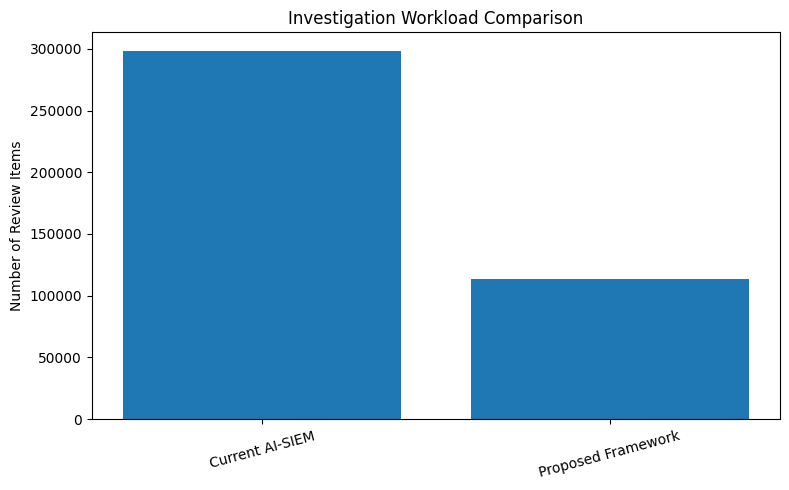

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.bar(
    investigation_results["Approach"],
    investigation_results["Review Items"]
)
plt.ylabel("Number of Review Items")
plt.title("Investigation Workload Comparison")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("investigation_workload_comparison.png", dpi=300)
plt.show()

---
## Experiment 4 — Automated Response Recommendation

### 15. Playbook Mapping by Category × IncidentGrade

Maps each alert to a recommended response action using a decision matrix.

**Decision logic:**

| IncidentGrade | Action |
|--------------|--------|
| `TruePositive` | `Immediate action:` + category-specific containment step |
| `BenignPositive` | `Validate and monitor:` + category-specific guidance |
| `FalsePositive` | `No containment; tune detection logic` |
| Unknown | `Analyst review required` |

**Categories with specific playbooks:** Malware, Phishing, CredentialAccess, CommandAndControl, Exfiltration, Reconnaissance, Persistence, PrivilegeEscalation, Execution, InitialAccess, LateralMovement

The table below previews the first 20 mapped records.

In [22]:
response_map = {
    "Malware": "Isolate endpoint; run malware scan; collect forensic evidence",
    "Phishing": "Disable account; reset password; review MFA and mailbox rules",
    "CredentialAccess": "Reset credentials; revoke sessions; enforce MFA review",
    "CommandAndControl": "Block domain/IP; isolate endpoint; investigate process tree",
    "Exfiltration": "Block outbound channel; isolate host; review accessed data",
    "Reconnaissance": "Monitor source; block repeated scanning; increase logging",
    "Persistence": "Remove persistence mechanism; isolate host; review autoruns",
    "PrivilegeEscalation": "Disable affected account; review admin group changes",
    "Execution": "Isolate endpoint if confirmed; collect process and command-line evidence",
    "InitialAccess": "Validate access source; reset credentials if account compromise is suspected",
    "LateralMovement": "Isolate affected hosts; review authentication paths and admin activity"
}

def recommend_response(row):
    category = str(row.get("Category", "Unknown"))
    grade = str(row.get("IncidentGrade", "Unknown"))

    base_response = response_map.get(category, "Analyst review required")

    if grade == "TruePositive":
        return "Immediate action: " + base_response
    elif grade == "BenignPositive":
        return "Validate and monitor: " + base_response
    elif grade == "FalsePositive":
        return "No containment; tune detection logic"
    else:
        return "Analyst review required"

raw_df["RecommendedResponse"] = raw_df.apply(recommend_response, axis=1)

response_results = raw_df[["Category", "IncidentGrade", "RecommendedResponse"]].head(20)

response_results

,Category,IncidentGrade,RecommendedResponse
0,InitialAccess,TruePositive,Immediate action: Validate access source; rese...
1,Exfiltration,FalsePositive,No containment; tune detection logic
2,InitialAccess,FalsePositive,No containment; tune detection logic
3,CommandAndControl,BenignPositive,Validate and monitor: Block domain/IP; isolate...
4,Execution,TruePositive,Immediate action: Isolate endpoint if confirme...
5,InitialAccess,FalsePositive,No containment; tune detection logic
6,CommandAndControl,BenignPositive,Validate and monitor: Block domain/IP; isolate...
7,Exfiltration,BenignPositive,Validate and monitor: Block outbound channel; ...
8,SuspiciousActivity,BenignPositive,Validate and monitor: Analyst review required
9,InitialAccess,TruePositive,Immediate action: Validate access source; rese...


---
### 16. Response Summary by IncidentGrade

**Table: Response Recommendation Summary**

- `TotalRecords` — how many alerts received each grade
- `UniqueResponses` — how many distinct response actions were issued for that grade

> **Generates:** `table_response_summary.csv`  
> **Feeds into:** Figure 4

In [23]:
response_summary = raw_df.groupby(["IncidentGrade"]).agg(
    TotalRecords=("IncidentGrade", "count"),
    UniqueResponses=("RecommendedResponse", "nunique")
).reset_index()

response_summary

,IncidentGrade,TotalRecords,UniqueResponses
0,BenignPositive,129268,10
1,FalsePositive,64306,1
2,TruePositive,104842,10


---
### 17. Top 15 Response Actions

**Table: Response Action Distribution**

The 15 most frequently issued response actions across the dataset.  
High counts for `Immediate action:` entries confirm a large proportion of true positive incidents.

> **Generates:** `table_response_action_distribution.csv`

In [24]:
response_action_distribution = raw_df["RecommendedResponse"].value_counts().head(15).reset_index()
response_action_distribution.columns = ["Recommended Response", "Count"]

response_action_distribution

,Recommended Response,Count
0,Immediate action: Validate access source; rese...,71477
1,No containment; tune detection logic,64306
2,Validate and monitor: Block outbound channel; ...,34045
3,Validate and monitor: Validate access source; ...,33553
4,Validate and monitor: Analyst review required,30391
5,Immediate action: Analyst review required,20465
6,Validate and monitor: Block domain/IP; isolate...,17757
7,Validate and monitor: Isolate endpoint if conf...,4240
8,Validate and monitor: Reset credentials; revok...,3713
9,Immediate action: Block domain/IP; isolate end...,3580


---
## Save All Result Tables

### 18. Export to CSV and Excel

Saves every result table as an individual CSV and as a single multi-sheet Excel workbook.

| Sheet | Content |
|-------|---------|
| Detection Performance | Accuracy, Precision, Recall, F1 |
| Prioritisation | TP rate at Top 10/20/25/30% |
| Investigation | Alert rows vs incident groups |
| Response Summary | Records and responses per IncidentGrade |
| Response Distribution | Top 15 most issued response actions |

In [25]:
# Save result tables to CSV
pd.DataFrame([current_results]).to_csv("table_detection_performance.csv", index=False)
top_percentage_results.to_csv("table_prioritisation_comparison.csv", index=False)
investigation_results.to_csv("table_investigation_workload.csv", index=False)
response_summary.to_csv("table_response_summary.csv", index=False)
response_action_distribution.to_csv("table_response_action_distribution.csv", index=False)

# Save all tables into one Excel file
with pd.ExcelWriter("SIEM_Framework_Results_Tables.xlsx") as writer:
    pd.DataFrame([current_results]).to_excel(writer, sheet_name="Detection Performance", index=False)
    top_percentage_results.to_excel(writer, sheet_name="Prioritisation", index=False)
    investigation_results.to_excel(writer, sheet_name="Investigation", index=False)
    response_summary.to_excel(writer, sheet_name="Response Summary", index=False)
    response_action_distribution.to_excel(writer, sheet_name="Response Distribution", index=False)

print("Tables saved successfully.")

Tables saved successfully.


---
## Figures

### 19. Figure 2 — Alert Prioritisation Line Chart

**Figure 2: True Positive Rate — Current AI-SIEM vs Proposed Framework**

Each x-axis point = top N% of alerts reviewed (ranked by each method).  
Y-axis = fraction of those reviewed alerts that are genuine `TruePositive` incidents.

- A **higher line** means the approach surfaces more real incidents within the same review budget
- The gap between lines shows the improvement from the context-aware hybrid score

> **Saves:** `figure_prioritisation_comparison.png` (300 dpi)

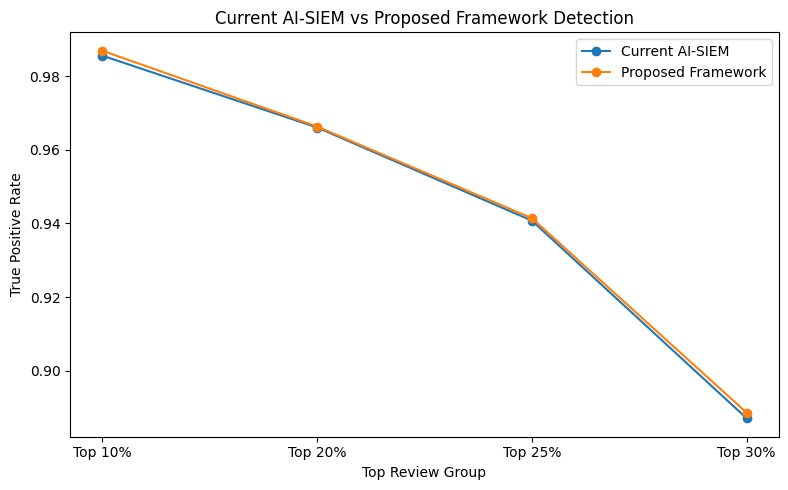

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(top_percentage_results["Top Percentage"], top_percentage_results["Current AI-SIEM"], marker="o", label="Current AI-SIEM")
plt.plot(top_percentage_results["Top Percentage"], top_percentage_results["Proposed Framework"], marker="o", label="Proposed Framework")
plt.ylabel("True Positive Rate")
plt.xlabel("Top Review Group")
plt.title("Current AI-SIEM vs Proposed Framework Detection")
plt.legend()
plt.tight_layout()
plt.savefig("figure_prioritisation_comparison.png", dpi=300)
plt.show()

---
### 20. Figure 3 — Investigation Workload Bar Chart

**Figure 3: Number of Review Items — Current AI-SIEM vs Proposed Framework**

The shorter bar (Proposed Framework) shows the reduction in items analysts need to review  
when alerts are grouped into incidents rather than reviewed individually.

> **Saves:** `figure_investigation_workload.png` (300 dpi)

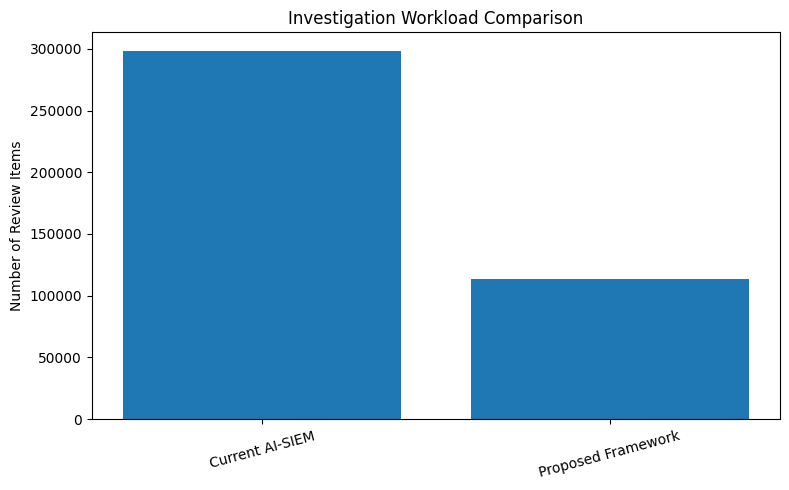

In [27]:
plt.figure(figsize=(8, 5))
plt.bar(investigation_results["Approach"], investigation_results["Review Items"])
plt.ylabel("Number of Review Items")
plt.title("Investigation Workload Comparison")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("figure_investigation_workload.png", dpi=300)
plt.show()

---
### 21. Figure 4 — Response Recommendation by Incident Grade

**Figure 4: Response Recommendation Volume by Incident Grade**

Shows how many records in the dataset received each `IncidentGrade`.  
This reflects the class distribution of the GUIDE dataset after processing.

> **Saves:** `figure_response_summary.png` (300 dpi)

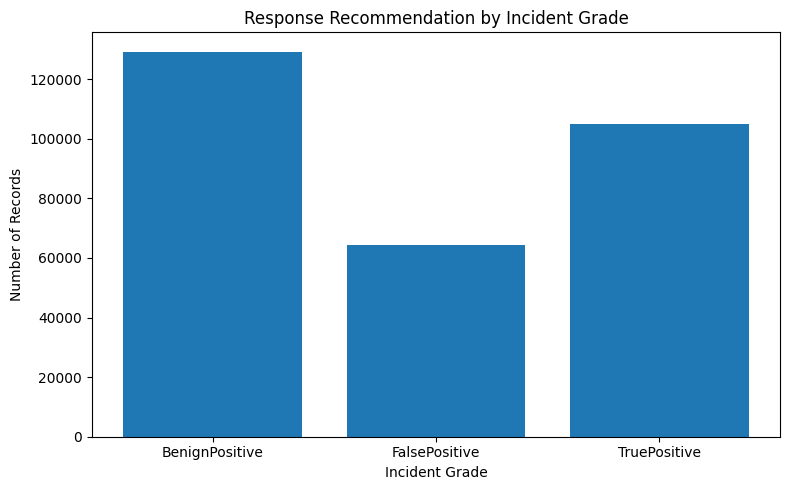

In [28]:
plt.figure(figsize=(8, 5))
plt.bar(response_summary["IncidentGrade"], response_summary["TotalRecords"])
plt.ylabel("Number of Records")
plt.xlabel("Incident Grade")
plt.title("Response Recommendation by Incident Grade")
plt.tight_layout()
plt.savefig("figure_response_summary.png", dpi=300)
plt.show()

---
### 22. Figure 1 — Normalised Confusion Matrix

**Figure 1: Normalised Confusion Matrix — Current AI-SIEM Model (%)**

Each cell shows the **percentage** of actual class (row) predicted as each class (column).  
Rows sum to 100%. The diagonal shows correct classification rates per class.

- High diagonal = model predicts that class well
- Off-diagonal = misclassification patterns (e.g. FalsePositive misclassified as BenignPositive)

> **Saves:** `figure_normalised_confusion_matrix.png` (300 dpi)

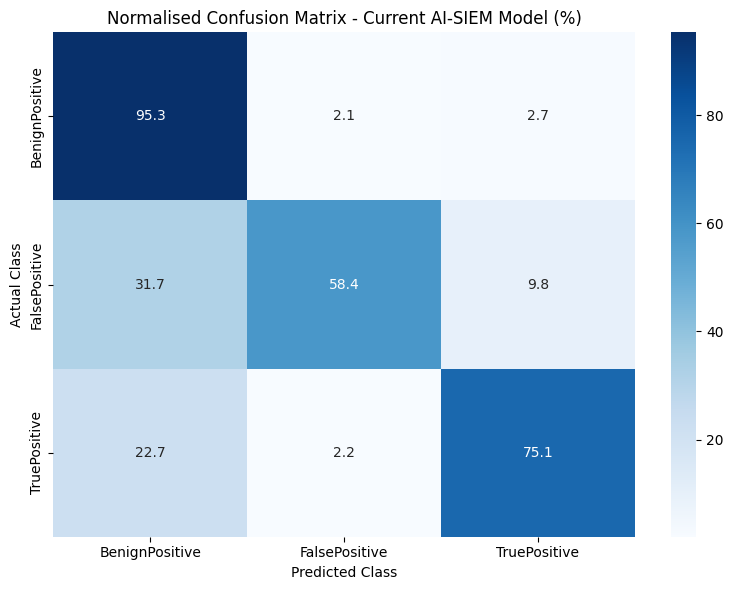

In [30]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(y_test, current_preds)

# Convert to percentages by row
cm_percent = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis] * 100

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_percent,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    xticklabels=target_encoder.classes_,
    yticklabels=target_encoder.classes_
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Normalised Confusion Matrix - Current AI-SIEM Model (%)")
plt.tight_layout()
plt.savefig("figure_normalised_confusion_matrix.png", dpi=300)
plt.show()

---
### 23. Per-Class Accuracy Table

**Table: Correct Classification Rate per Incident Grade**

Extracts the diagonal of the confusion matrix to show accuracy per class individually.  
Useful for identifying which incident types the model handles well vs. which need improvement.

**Actual per-class accuracy from the run is shown below.**

In [31]:
cm = confusion_matrix(y_test, current_preds)
classes = target_encoder.classes_

per_class_accuracy = cm.diagonal() / cm.sum(axis=1)

class_accuracy_table = pd.DataFrame({
    "Incident Grade": classes,
    "Correct Classification Rate": per_class_accuracy
})

class_accuracy_table

,Incident Grade,Correct Classification Rate
0,BenignPositive,0.952889
1,FalsePositive,0.584091
2,TruePositive,0.751395
